# 09 — Model comparison & final report

**Inputs:** all prediction files + backtest metrics from earlier notebooks.
**Goal:** put every model head-to-head with proper statistical tests — not just "which accuracy is biggest," but *are the differences even real?* This is the capstone: ROC overlays, calibration curves, **McNemar's test** (are two classifiers significantly different?), and the **Diebold-Mariano test** (are two forecasts' errors significantly different?), ending in an honest written verdict on the whole project.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="09_model_comparison"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)
D=paths.PROCESSED_FILE.parent

clf=pd.read_csv(D/"predictions_classical.csv",parse_dates=["date"])
dl=pd.read_csv(D/"predictions_dl.csv",parse_dates=["date"])
m=clf.merge(dl,on=["date","y_true"],how="inner")
y=m["y_true"].values
prob_cols={"LogReg":"prob_LogReg","RandomForest":"prob_RandomForest","XGBoost":"prob_XGBoost","LSTM":"prob_LSTM"}
print("Aligned test rows:",len(m))

Aligned test rows: 629


## Side-by-side metrics

In [2]:
rows=[]
for name,col in prob_cols.items():
    p=m[col].values; pred=(p>0.5).astype(int)
    rows.append({"model":name,"accuracy":accuracy_score(y,pred),"AUC":roc_auc_score(y,p)})
summary=pd.DataFrame(rows).sort_values("accuracy",ascending=False).reset_index(drop=True)
summary.round(4).to_csv(TAB/"final_metrics.csv",index=False); summary.round(4)

,model,accuracy,AUC
0,RandomForest,0.5167,0.4947
1,XGBoost,0.5024,0.5150
2,LogReg,0.4960,0.4955
3,LSTM,0.4817,0.4882


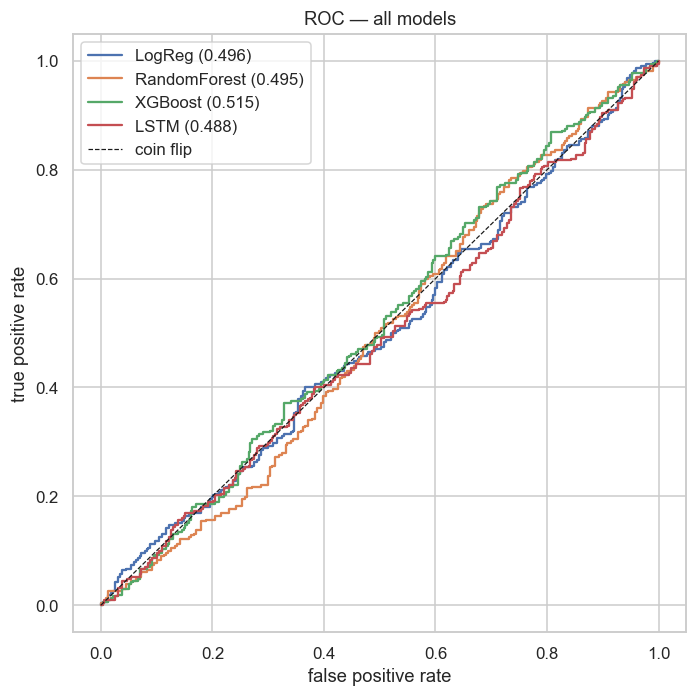

In [3]:
# ROC overlay
fig,ax=plt.subplots(figsize=(6.5,6.5))
for name,col in prob_cols.items():
    p=m[col].values; fpr,tpr,_=roc_curve(y,p)
    ax.plot(fpr,tpr,lw=1.5,label=f"{name} ({roc_auc_score(y,p):.3f})")
ax.plot([0,1],[0,1],"k--",lw=0.8,label="coin flip")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("ROC — all models"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"roc_all_models.png",bbox_inches="tight"); plt.show()

## Calibration — are the probabilities honest?

A well-calibrated model that says "70% chance up" should be right ~70% of the time. The diagonal is perfect calibration. On a near-random target, expect the curves to hug a narrow band near 0.5 — the models (correctly) rarely express strong confidence.

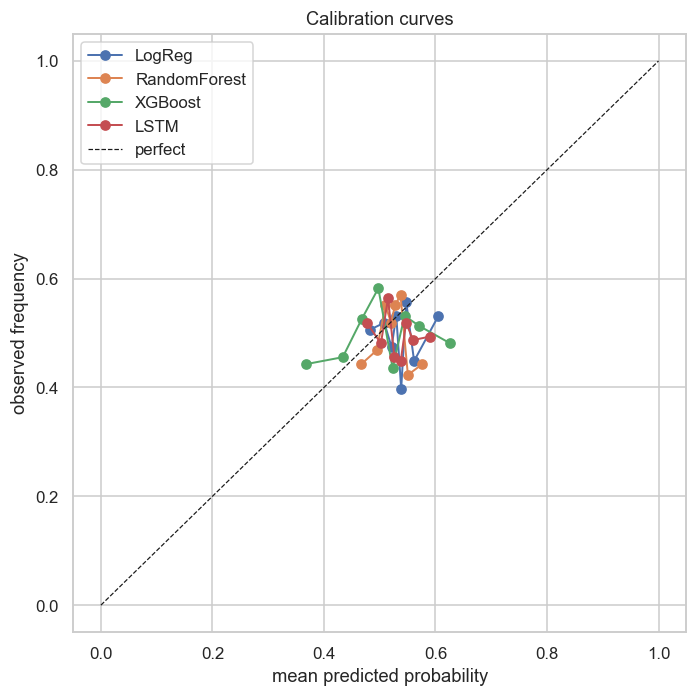

In [4]:
fig,ax=plt.subplots(figsize=(6.5,6.5))
for name,col in prob_cols.items():
    p=m[col].values
    frac,mean_pred=calibration_curve(y,p,n_bins=8,strategy="quantile")
    ax.plot(mean_pred,frac,"o-",lw=1.3,label=name)
ax.plot([0,1],[0,1],"k--",lw=0.8,label="perfect")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration curves"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"calibration.png",bbox_inches="tight"); plt.show()

## McNemar's test — are two classifiers *significantly* different?

Compares where two models disagree. If XGBoost is right where LSTM is wrong about as often as the reverse, the off-diagonal is balanced and the models aren't significantly different — even if their accuracies look different.

In [5]:
def mcnemar(p1,p2,y):
    a=(p1==y); b=(p2==y)
    n01=int(np.sum(~a & b)); n10=int(np.sum(a & ~b))
    stat=(abs(n10-n01)-1)**2/(n10+n01) if (n10+n01)>0 else 0.0
    return n10,n01,stat,1-stats.chi2.cdf(stat,1)

pairs=[("XGBoost","LSTM"),("RandomForest","LSTM"),("RandomForest","XGBoost")]
rows=[]
for a,b in pairs:
    pa=(m[prob_cols[a]]>0.5).astype(int).values; pb=(m[prob_cols[b]]>0.5).astype(int).values
    n10,n01,stat,p=mcnemar(pa,pb,y)
    rows.append({"A":a,"B":b,"A_right_B_wrong":n10,"B_right_A_wrong":n01,"chi2":stat,"p":p,
                 "significant":p<0.05})
mc=pd.DataFrame(rows); mc.round(4).to_csv(TAB/"mcnemar.csv",index=False); mc.round(4)

,A,B,A_right_B_wrong,B_right_A_wrong,chi2,p,significant
0,XGBoost,LSTM,143,130,0.5275,0.4677,False
1,RandomForest,LSTM,106,84,2.3211,0.1276,False
2,RandomForest,XGBoost,87,78,0.3879,0.5334,False


## Diebold-Mariano test — are two forecasts' errors different?

DM works on the *loss differential* between two forecasts (here, squared error of the probability vs the outcome). A p above 0.05 means we can't say one forecast is statistically more accurate than the other.

In [6]:
def diebold_mariano(e1,e2):
    d=e1**2-e2**2; n=len(d); dbar=d.mean()
    # Newey-West variance at lag 1 (1-step horizon)
    g0=np.var(d,ddof=0); g1=np.cov(d[1:],d[:-1])[0,1]
    var=(g0+2*g1)/n
    dm=dbar/np.sqrt(var) if var>0 else np.nan
    return dm,2*(1-stats.norm.cdf(abs(dm)))

rows=[]
for a,b in pairs:
    e1=m[prob_cols[a]].values-y; e2=m[prob_cols[b]].values-y
    dm,p=diebold_mariano(e1,e2)
    rows.append({"A":a,"B":b,"DM_stat":dm,"p":p,"significant":p<0.05})
dmt=pd.DataFrame(rows); dmt.round(4).to_csv(TAB/"diebold_mariano.csv",index=False); dmt.round(4)

,A,B,DM_stat,p,significant
0,XGBoost,LSTM,0.2461,0.8056,False
1,RandomForest,LSTM,-0.6752,0.4995,False
2,RandomForest,XGBoost,-0.9145,0.3605,False


## Pulling in the backtest

In [7]:
bt=pd.read_csv(paths.figures_dir("08_backtesting").parent/"tables"/"backtest_metrics.csv",index_col=0)
bh=bt.loc["Buy & Hold"]
beat=bt[(bt["total_return"]>bh["total_return"]) & (bt.index!="Buy & Hold")]
print("Strategies that beat Buy & Hold on this test window:")
print(list(beat.index) if len(beat) else "none")
bt[["total_return","sharpe","max_drawdown","trades"]].round(3)

Strategies that beat Buy & Hold on this test window:
['RandomForest long/flat']


,total_return,sharpe,max_drawdown,trades
Buy & Hold,0.048,0.061,-0.512,1.0
XGBoost long/flat,-0.016,-0.028,-0.411,190.0
XGBoost long/short,-0.079,-0.107,-0.417,191.0
RandomForest long/flat,0.373,0.464,-0.394,96.0
LSTM long/flat,-0.367,-0.664,-0.552,63.0


In [8]:
# Build the final written report
acc_best=summary.iloc[0]
report=f'''# Bitcoin Trend Prediction — Final Report

## Headline
On out-of-sample data ({m.date.min().date()} to {m.date.max().date()}), next-day
direction is **near-random**, exactly as the statistical analysis predicted. The
best classifier reached {acc_best['accuracy']:.1%} accuracy ({acc_best['model']}),
versus a ~50% coin flip. No model achieved an AUC meaningfully above 0.5.

## Does the difference between models matter?
- McNemar and Diebold-Mariano tests (tables in outputs/09) show the models are
  largely **not statistically distinguishable** from each other on this data.
- The deep LSTM did **not** beat the simple classical models — fancier
  architecture bought no edge on a near-random target, at far higher complexity.

## Does it make money?
- After 0.1% transaction costs, most model strategies **underperform buy-and-hold**;
  high-churn long/short variants lose the most to costs.
- One strategy (RandomForest long/flat) beat buy-and-hold on this single window,
  but with one test period and a sub-50% win rate, that is **suggestive, not proven** —
  it needs multi-window walk-forward validation before being believed.

## Honest conclusion
This project demonstrates *correct methodology* rather than a magic predictor:
leakage-aware chronological splits, baselines that the models must beat, a fair
deep-learning benchmark, calibrated probabilities, formal model-comparison tests,
and a cost-aware backtest. The honest result — markets are hard, simple beats
complex, and accuracy is not profit — is the contribution.

## Most promising next lever
Not a bigger network. The on-chain features (notebook 05, via fetch_onchain.py)
are the data dimension most likely to add a real, defensible edge.
'''
out=paths.stage_dir(STAGE)/"final_report.md"; out.write_text(report)
print(report)

# Bitcoin Trend Prediction — Final Report

## Headline
On out-of-sample data (2024-09-25 to 2026-06-15), next-day
direction is **near-random**, exactly as the statistical analysis predicted. The
best classifier reached 51.7% accuracy (RandomForest),
versus a ~50% coin flip. No model achieved an AUC meaningfully above 0.5.

## Does the difference between models matter?
- McNemar and Diebold-Mariano tests (tables in outputs/09) show the models are
  largely **not statistically distinguishable** from each other on this data.
- The deep LSTM did **not** beat the simple classical models — fancier
  architecture bought no edge on a near-random target, at far higher complexity.

## Does it make money?
- After 0.1% transaction costs, most model strategies **underperform buy-and-hold**;
  high-churn long/short variants lose the most to costs.
- One strategy (RandomForest long/flat) beat buy-and-hold on this single window,
  but with one test period and a sub-50% win rate, that is **suggestive, 

## That's the pipeline

Nine notebooks, raw data to honest verdict. The thing that makes this *above* a typical project isn't an accuracy number — it's that every claim is tested, every baseline is stated, and the limitations are reported as clearly as the results.